In [1]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
os.makedirs("charts", exist_ok=True)

PALETTE = {
    "Extreme Fear": "#8B0000",
    "Fear":         "#E05C5C",
    "Neutral":      "#8888AA",
    "Greed":        "#5CA85C",
    "Extreme Greed":"#006400"
}
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("✓ Imports OK")

✓ Imports OK


In [2]:
fg = pd.read_csv("fear_greed_index.csv")
ht = pd.read_csv("historical_data.csv")

for name, df in [("Fear/Greed Index", fg), ("Historical Trades", ht)]:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Rows × Cols  : {df.shape[0]:,} × {df.shape[1]}")
    print(f"  Columns      : {df.columns.tolist()}")
    print(f"  Missing vals :\n{df.isna().sum()[df.isna().sum() > 0]}")
    print(f"  Duplicates   : {df.duplicated().sum()}")
    print(df.head(3).to_string())


  Fear/Greed Index
  Rows × Cols  : 2,644 × 4
  Columns      : ['timestamp', 'value', 'classification', 'date']
  Missing vals :
Series([], dtype: int64)
  Duplicates   : 0
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

  Historical Trades
  Rows × Cols  : 211,224 × 16
  Columns      : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
  Missing vals :
Series([], dtype: int64)
  Duplicates   : 0
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  Closed PnL                                                    Transaction Hash     Order ID  Crossed       Fee      Trade ID     Timestamp
0  0xae5eacaf

In [3]:
ts_col = next((c for c in ht.columns if "time" in c.lower()), None)
print(f"Timestamp column: '{ts_col}'")
print("Sample raw values:", ht[ts_col].dropna().head(5).tolist())

def clean_timestamp(val):
    if pd.isna(val):
        return pd.NaT
    s = str(val).strip()
    for noise in ["IST", "UTC", "GMT", "EST", "PST"]:
        s = s.replace(noise, "").strip()
    formats = [
        "%Y-%m-%d %H:%M:%S", "%d-%m-%Y %H:%M:%S", "%d/%m/%Y %H:%M:%S",
        "%Y/%m/%d %H:%M:%S", "%Y-%m-%dT%H:%M:%S", "%d %b %Y %H:%M:%S",
        "%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y",
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    try:
        return pd.to_datetime(s, infer_datetime_format=True, dayfirst=True)
    except Exception:
        return pd.NaT

if pd.api.types.is_numeric_dtype(ht[ts_col]):
    sample = ht[ts_col].dropna().iloc[0]
    unit = "ms" if sample > 1e12 else "s"
    ht["parsed_ts"] = pd.to_datetime(ht[ts_col], unit=unit, errors="coerce")
    print(f"Interpreted as Unix timestamp (unit={unit})")
else:
    ht["parsed_ts"] = ht[ts_col].apply(clean_timestamp)

failed = ht["parsed_ts"].isna().sum()
print(f"\nParsed OK : {len(ht) - failed:,}  |  Failed : {failed:,}")
if failed > 0:
    print("Failed samples:", ht[ht["parsed_ts"].isna()][ts_col].unique()[:5])

ht["date"] = pd.to_datetime(ht["parsed_ts"].dt.date)

date_col = next((c for c in fg.columns if "date" in c.lower()), fg.columns[0])
cls_col  = next((c for c in fg.columns if "class" in c.lower() or "sentiment" in c.lower()),
                [c for c in fg.columns if c != date_col][0])

fg["date"]           = pd.to_datetime(fg[date_col], errors="coerce", dayfirst=True)
fg["classification"] = fg[cls_col].astype(str).str.strip().str.title()
fg = fg.dropna(subset=["date"]).drop_duplicates("date")[["date", "classification"]]

print("\nSentiment classes:", fg["classification"].value_counts().to_dict())
print(f"Fear/Greed date range: {fg['date'].min().date()} → {fg['date'].max().date()}")
print(f"Trades date range    : {ht['date'].min().date()} → {ht['date'].max().date()}")

Timestamp column: 'Timestamp IST'
Sample raw values: ['02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50']

Parsed OK : 211,224  |  Failed : 0

Sentiment classes: {'Fear': 330, 'Greed': 252, 'Extreme Fear': 187, 'Neutral': 147, 'Extreme Greed': 130}
Fear/Greed date range: 2018-01-02 → 2025-12-04
Trades date range    : 2023-05-01 → 2025-05-01


In [8]:
def find_col(df, *keywords):
    for c in df.columns:
        for k in keywords:
            if k.lower() in c.lower():
                return c
    return None

pnl_col  = find_col(ht, "closedpnl", "pnl", "profit", "realised")
size_col = find_col(ht, "sz", "size", "notional", "qty", "amount")
side_col = find_col(ht, "side", "direction", "type")
lev_col  = find_col(ht, "leverage", "lev")
acct_col = find_col(ht, "account", "trader", "wallet", "address", "user")
sym_col  = find_col(ht, "symbol", "coin", "asset", "ticker")

print(f"PnL col   : {pnl_col}")
print(f"Size col  : {size_col}")
print(f"Side col  : {side_col}")
print(f"Leverage  : {lev_col}")
print(f"Account   : {acct_col}")
print(f"Symbol    : {sym_col}")

for c in [pnl_col, size_col, lev_col]:
    if c:
        ht[c] = pd.to_numeric(ht[c], errors="coerce")

ht["win"] = (ht[pnl_col] > 0).astype(int) if pnl_col else 0

agg = {"win": ["sum", "count"]}
if pnl_col:  agg[pnl_col]  = ["sum", "mean", "std"]
if size_col: agg[size_col] = "mean"
if lev_col:  agg[lev_col]  = ["mean", "max"]

daily = ht.groupby("date").agg(agg)
daily.columns = ["_".join(c).strip("_") for c in daily.columns]
daily = daily.rename(columns={
    "win_sum":   "wins",
    "win_count": "trade_count",
    f"{pnl_col}_sum"   if pnl_col  else "__": "total_pnl",
    f"{pnl_col}_mean"  if pnl_col  else "__": "mean_pnl",
    f"{pnl_col}_std"   if pnl_col  else "__": "pnl_std",
    f"{size_col}_mean" if size_col else "__": "avg_size",
    f"{lev_col}_mean"  if lev_col  else "__": "avg_leverage",
    f"{lev_col}_max"   if lev_col  else "__": "max_leverage",
}).reset_index()

daily["win_rate"]       = daily["wins"] / daily["trade_count"]
daily["drawdown_proxy"] = daily["total_pnl"].clip(upper=0).abs()

if side_col:
    ht["side_clean"] = ht[side_col].astype(str).str.upper().str.strip()
    ls = ht.groupby("date")["side_clean"].value_counts().unstack(fill_value=0)
    long_k  = next((c for c in ls.columns if c.startswith(("L", "BUY"))),  None)
    short_k = next((c for c in ls.columns if c.startswith(("S", "SEL"))), None)
    if long_k and short_k:
        ls["long_short_ratio"] = ls[long_k] / (ls[short_k] + 1)
        daily = daily.merge(ls[["long_short_ratio"]].reset_index(), on="date", how="left")

print(f"\nDaily metrics shape: {daily.shape}")
print(daily.describe().round(2).to_string())

PnL col   : Closed PnL
Size col  : Size Tokens
Side col  : Side
Leverage  : None
Account   : Account
Symbol    : Coin

Daily metrics shape: (480, 10)
                      date     wins  trade_count  total_pnl  mean_pnl  pnl_std   avg_size  win_rate  drawdown_proxy  long_short_ratio
count                  480   480.00       480.00     480.00    480.00   474.00     480.00    480.00          480.00            480.00
mean   2024-08-25 17:00:00   180.98       440.05   21452.00     60.03   306.06    9962.23      0.37         2315.01              2.51
min    2023-05-01 00:00:00     0.00         1.00 -419020.23   -965.92     0.00       0.08      0.00            0.00              0.00
25%    2024-04-22 18:00:00     4.00        18.00       7.25      0.28    32.19     131.89      0.18            0.00              0.46
50%    2024-08-25 12:00:00    25.50        67.50    1118.96     17.96   102.59     780.02      0.35            0.00              0.89
75%    2025-01-01 06:00:00   189.00       520.

In [9]:
merged = daily.merge(fg, on="date", how="left")
merged["classification"] = merged["classification"].fillna("Unknown")
merged["sentiment_bin"]  = merged["classification"].replace({
    "Extreme Fear": "Fear", "Extreme Greed": "Greed"
})

sent_map = {"Extreme Fear": -2, "Fear": -1, "Neutral": 0,
            "Greed": 1, "Extreme Greed": 2}
merged["sentiment_num"] = merged["classification"].map(sent_map)

print(f"Merged shape  : {merged.shape}")
print(f"Date range    : {merged['date'].min().date()} → {merged['date'].max().date()}")
print("\nSentiment distribution:")
print(merged["classification"].value_counts())

Merged shape  : (480, 13)
Date range    : 2023-05-01 → 2025-05-01

Sentiment distribution:
classification
Unknown          322
Greed             56
Extreme Greed     43
Fear              37
Neutral           16
Extreme Fear       6
Name: count, dtype: int64


=== Performance by Sentiment ===
                total_pnl                       win_rate               drawdown_proxy                  
                     mean    median         std     mean median    std           mean median        std
classification                                                                                         
Extreme Fear      733.323    64.569    2798.334    0.307  0.274  0.366        401.112    0.0    962.713
Extreme Greed   26904.504   541.555  112472.212    0.320  0.292  0.254       2942.482    0.0  18696.465
Fear            48087.178  1147.596  132965.887    0.348  0.299  0.289        714.592    0.0   4192.733
Greed           10886.295   423.083   39493.424    0.362  0.340  0.285       2492.870    0.0  12774.544
Neutral          4666.046    97.704   10806.053    0.287  0.231  0.270        177.649    0.0    417.620
Unknown         20720.964  2041.650   60558.188    0.381  0.365  0.256       2526.046    0.0  24954.045


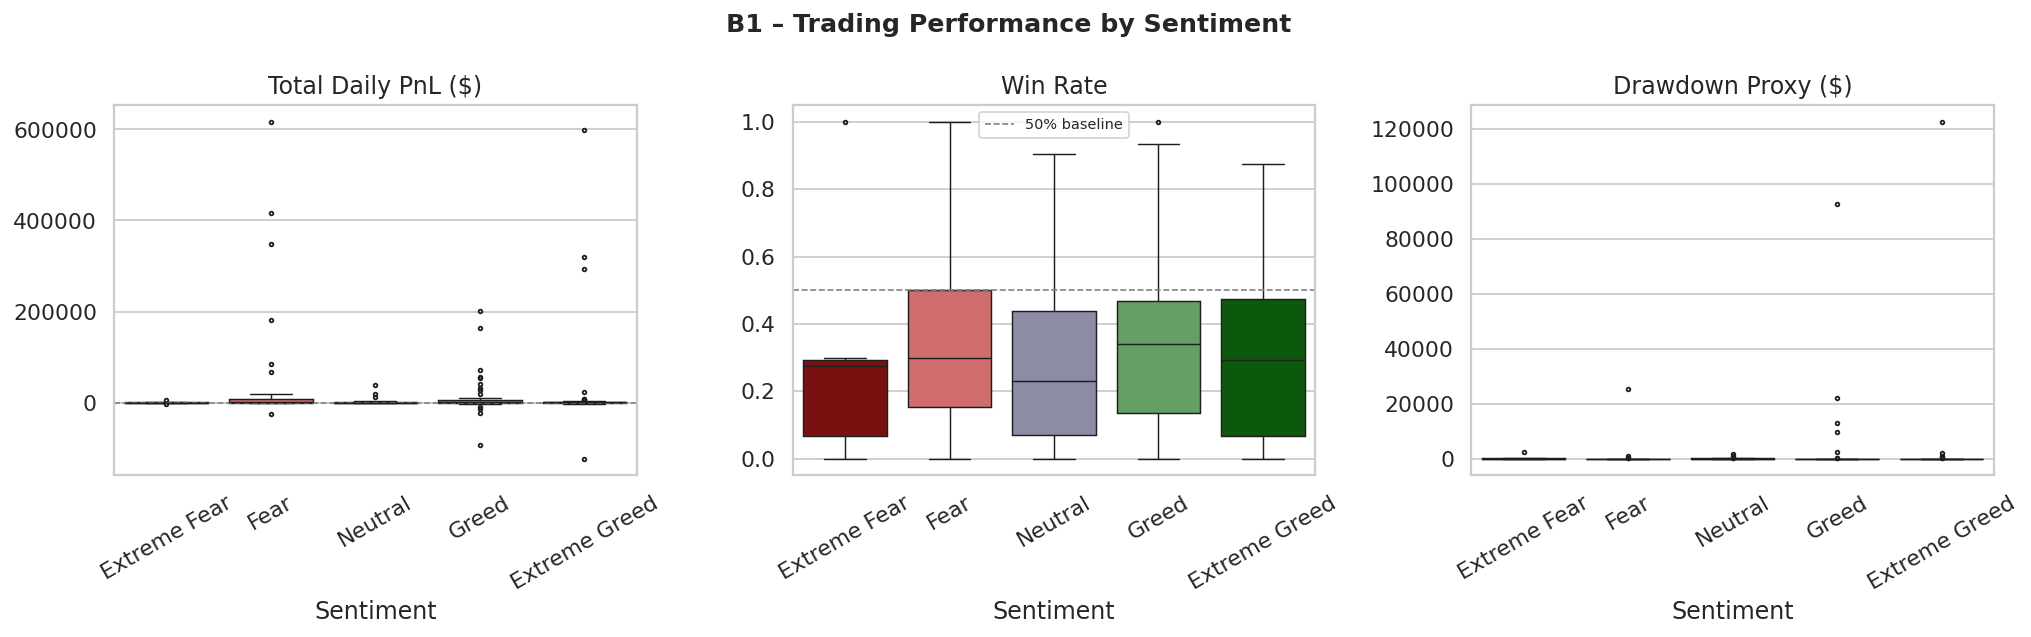

In [10]:
order = [s for s in ["Extreme Fear","Fear","Neutral","Greed","Extreme Greed"]
         if s in merged["classification"].unique()]
pal   = [PALETTE[s] for s in order]

perf_cols = [c for c in ["total_pnl","win_rate","drawdown_proxy"] if c in merged.columns]
summary = (merged.groupby("classification")[perf_cols]
           .agg(["mean","median","std"]).round(3))
print("=== Performance by Sentiment ===")
print(summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("B1 – Trading Performance by Sentiment", fontsize=14, fontweight="bold")

for ax, metric, title in zip(axes,
        ["total_pnl",       "win_rate",    "drawdown_proxy"],
        ["Total Daily PnL ($)", "Win Rate", "Drawdown Proxy ($)"]):
    if metric not in merged.columns:
        ax.set_visible(False); continue
    sns.boxplot(data=merged, x="classification", y=metric,
                order=order, palette=pal, ax=ax, linewidth=0.8, fliersize=2)
    ax.set_title(title); ax.set_xlabel("Sentiment"); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    if metric == "win_rate":
        ax.axhline(0.5, ls="--", color="gray", lw=0.9, label="50% baseline")
        ax.legend(fontsize=8)
    if metric == "total_pnl":
        ax.axhline(0, ls="--", color="gray", lw=0.9)

plt.tight_layout()
plt.savefig("charts/B1_performance.png", bbox_inches="tight")
plt.show()

=== Behaviour by Sentiment ===
                trade_count  avg_size  long_short_ratio
classification                                         
Extreme Fear         387.67    927.01              3.67
Extreme Greed        130.72  23912.59              3.08
Fear                 374.84  12007.34              2.59
Greed                201.64  23803.94              2.32
Neutral              172.25  17594.36              3.48
Unknown              544.60   5246.17              2.38


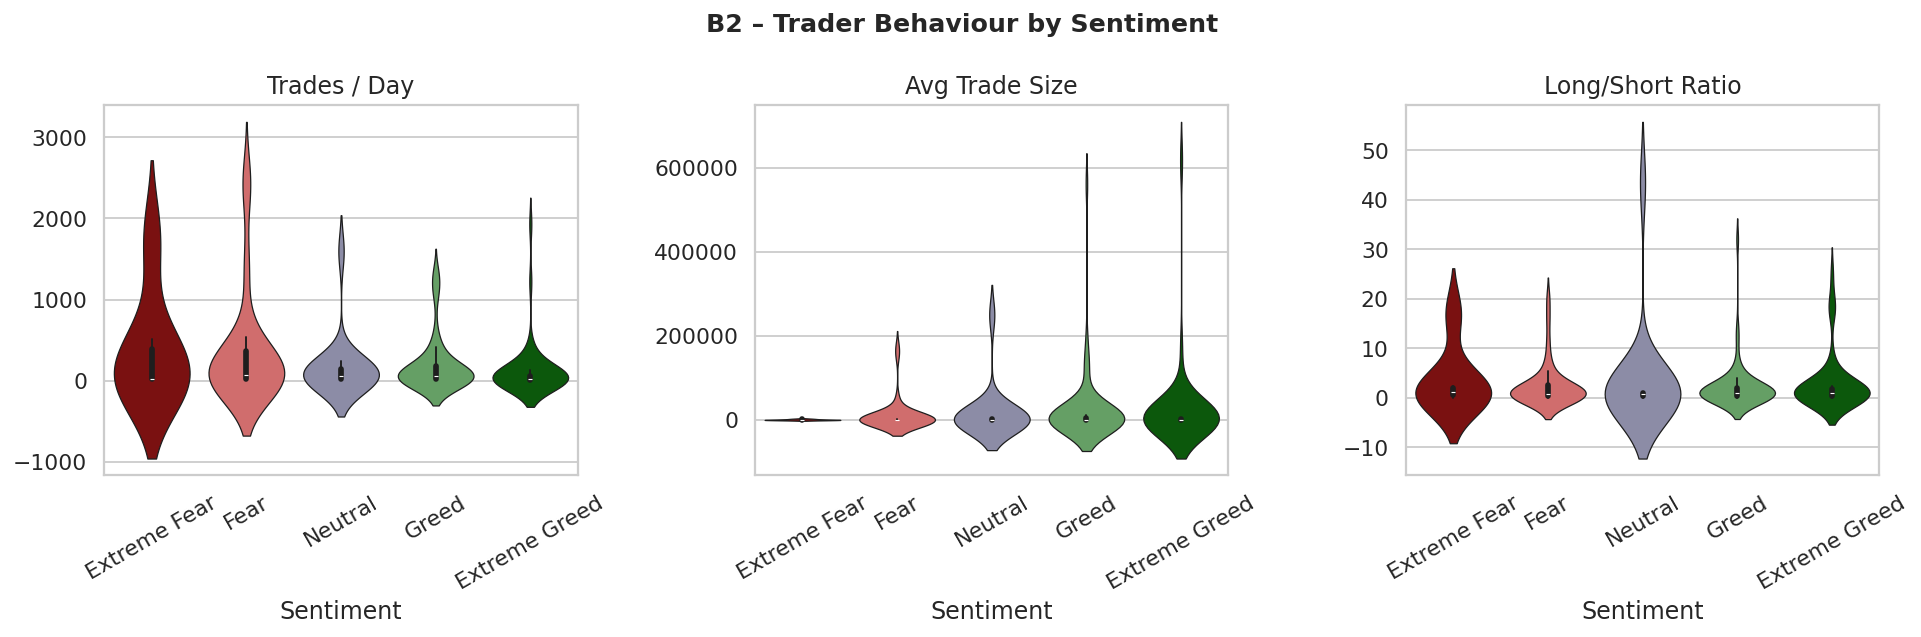

In [11]:
beh_cols = [c for c in ["trade_count","avg_leverage","avg_size","long_short_ratio"]
            if c in merged.columns]
beh_summary = merged.groupby("classification")[beh_cols].mean().round(2)
print("=== Behaviour by Sentiment ===")
print(beh_summary.to_string())

fig, axes = plt.subplots(1, len(beh_cols), figsize=(5 * len(beh_cols), 5))
if len(beh_cols) == 1: axes = [axes]
fig.suptitle("B2 – Trader Behaviour by Sentiment", fontsize=14, fontweight="bold")

titles = {"trade_count":"Trades / Day","avg_leverage":"Avg Leverage",
          "avg_size":"Avg Trade Size","long_short_ratio":"Long/Short Ratio"}

for ax, metric in zip(axes, beh_cols):
    sns.violinplot(data=merged, x="classification", y=metric,
                   order=order, palette=pal, ax=ax, inner="box", linewidth=0.7)
    ax.set_title(titles.get(metric, metric))
    ax.set_xlabel("Sentiment"); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("charts/B2_behaviour.png", bbox_inches="tight")
plt.show()

Unique traders : 32
seg_freq: {'Frequent': 16, 'Infrequent': 16}
seg_consistency: {'Others': 17, 'Consistent Winners': 15}


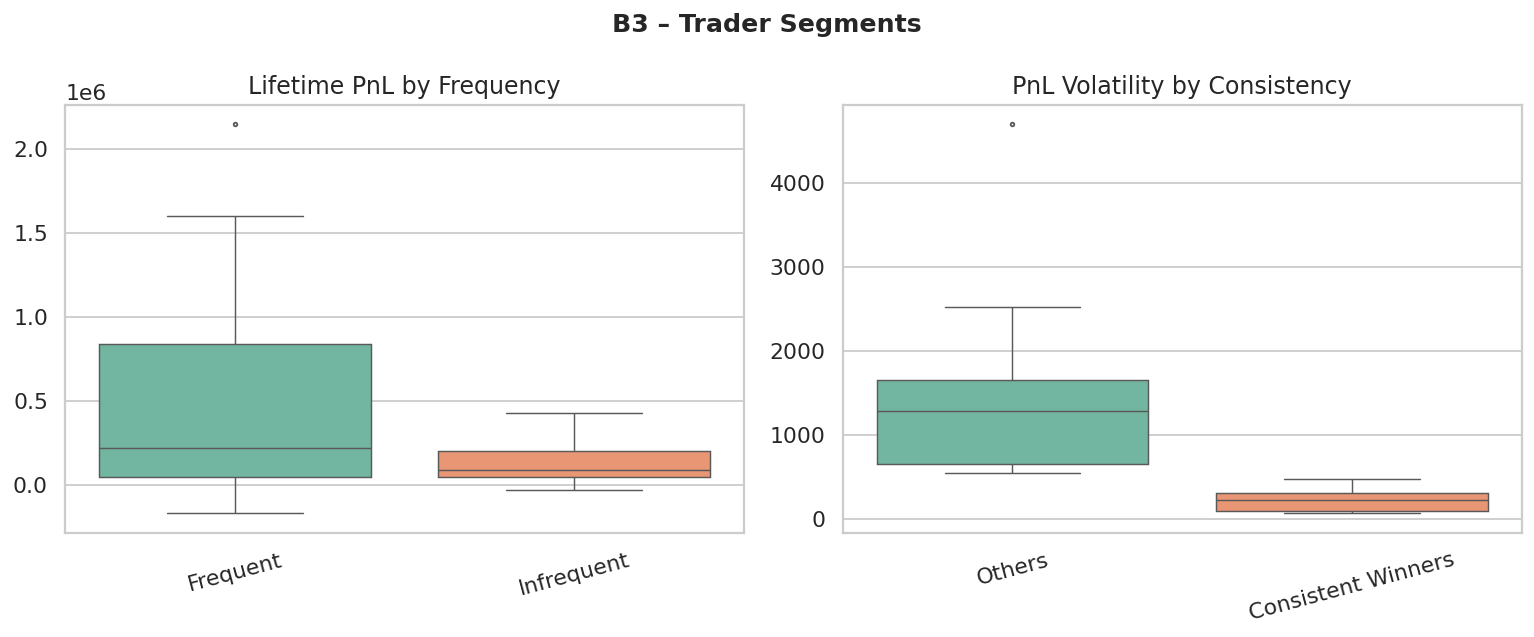

In [12]:
if acct_col:
    agg2 = {"win": ["sum","count"]}
    if pnl_col:  agg2[pnl_col]  = ["sum","std"]
    if lev_col:  agg2[lev_col]  = "mean"
    if size_col: agg2[size_col] = "mean"

    trader = ht.groupby(acct_col).agg(agg2)
    trader.columns = ["_".join(c).strip("_") for c in trader.columns]
    trader = trader.rename(columns={
        "win_sum":  "wins",  "win_count": "total_trades",
        f"{pnl_col}_sum"   if pnl_col  else "__": "lifetime_pnl",
        f"{pnl_col}_std"   if pnl_col  else "__": "pnl_volatility",
        f"{lev_col}_mean"  if lev_col  else "__": "avg_leverage",
        f"{size_col}_mean" if size_col else "__": "avg_size",
    }).reset_index()
    trader["win_rate"] = trader["wins"] / trader["total_trades"]

    if "avg_leverage" in trader.columns:
        lm = trader["avg_leverage"].median()
        trader["seg_leverage"] = np.where(trader["avg_leverage"] >= lm,
                                           "High Leverage", "Low Leverage")
    tm = trader["total_trades"].median()
    trader["seg_freq"] = np.where(trader["total_trades"] >= tm,
                                   "Frequent", "Infrequent")
    if "pnl_volatility" in trader.columns and "lifetime_pnl" in trader.columns:
        vm = trader["pnl_volatility"].median()
        trader["seg_consistency"] = np.where(
            (trader["lifetime_pnl"] > 0) & (trader["pnl_volatility"] < vm),
            "Consistent Winners", "Others")

    print(f"Unique traders : {len(trader):,}")
    for seg in ["seg_leverage","seg_freq","seg_consistency"]:
        if seg in trader.columns:
            print(f"{seg}: {trader[seg].value_counts().to_dict()}")

    seg_plots = [(s, m, t) for s, m, t in [
        ("seg_leverage",    "win_rate",       "Win Rate by Leverage Segment"),
        ("seg_freq",        "lifetime_pnl",   "Lifetime PnL by Frequency"),
        ("seg_consistency", "pnl_volatility", "PnL Volatility by Consistency"),
    ] if s in trader.columns and m in trader.columns]

    fig, axes = plt.subplots(1, len(seg_plots), figsize=(6 * len(seg_plots), 5))
    if len(seg_plots) == 1: axes = [axes]
    fig.suptitle("B3 – Trader Segments", fontsize=14, fontweight="bold")

    for ax, (seg, metric, title) in zip(axes, seg_plots):
        sns.boxplot(data=trader, x=seg, y=metric, ax=ax,
                    palette="Set2", linewidth=0.8, fliersize=2)
        ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.savefig("charts/B3_segments.png", bbox_inches="tight")
    plt.show()

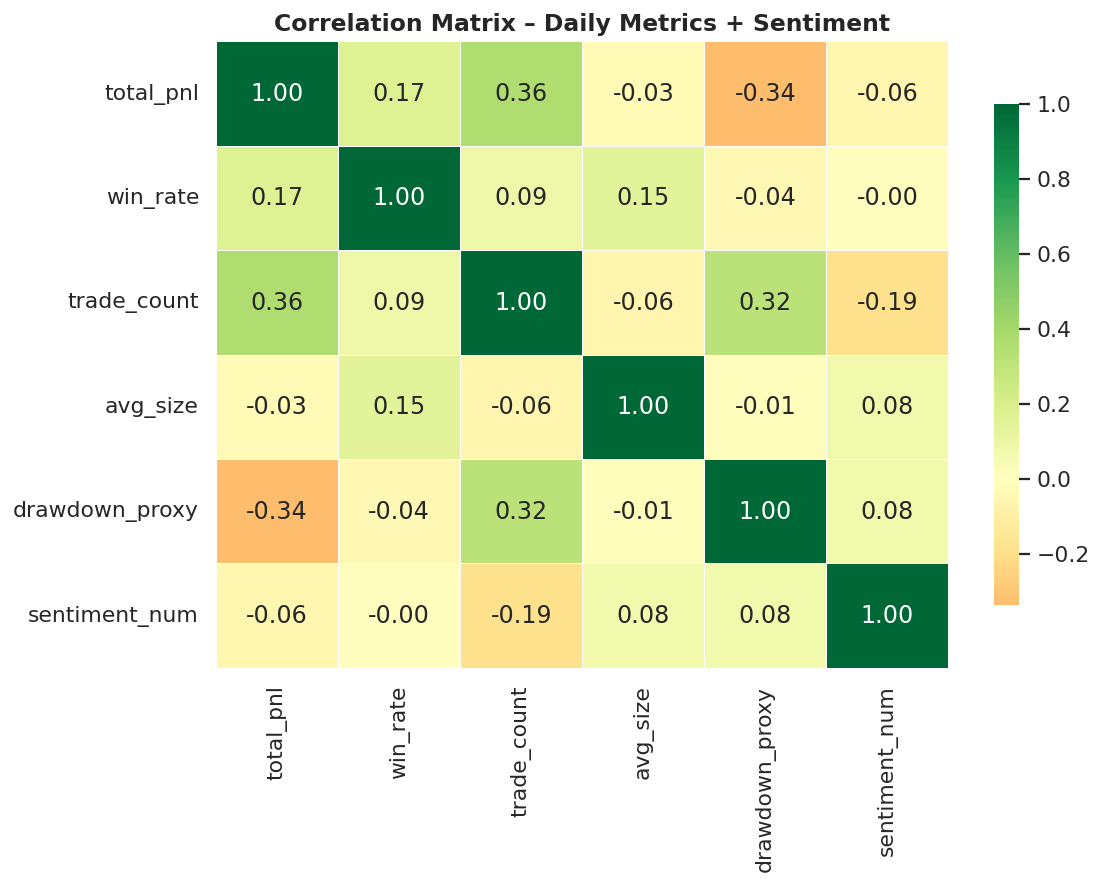

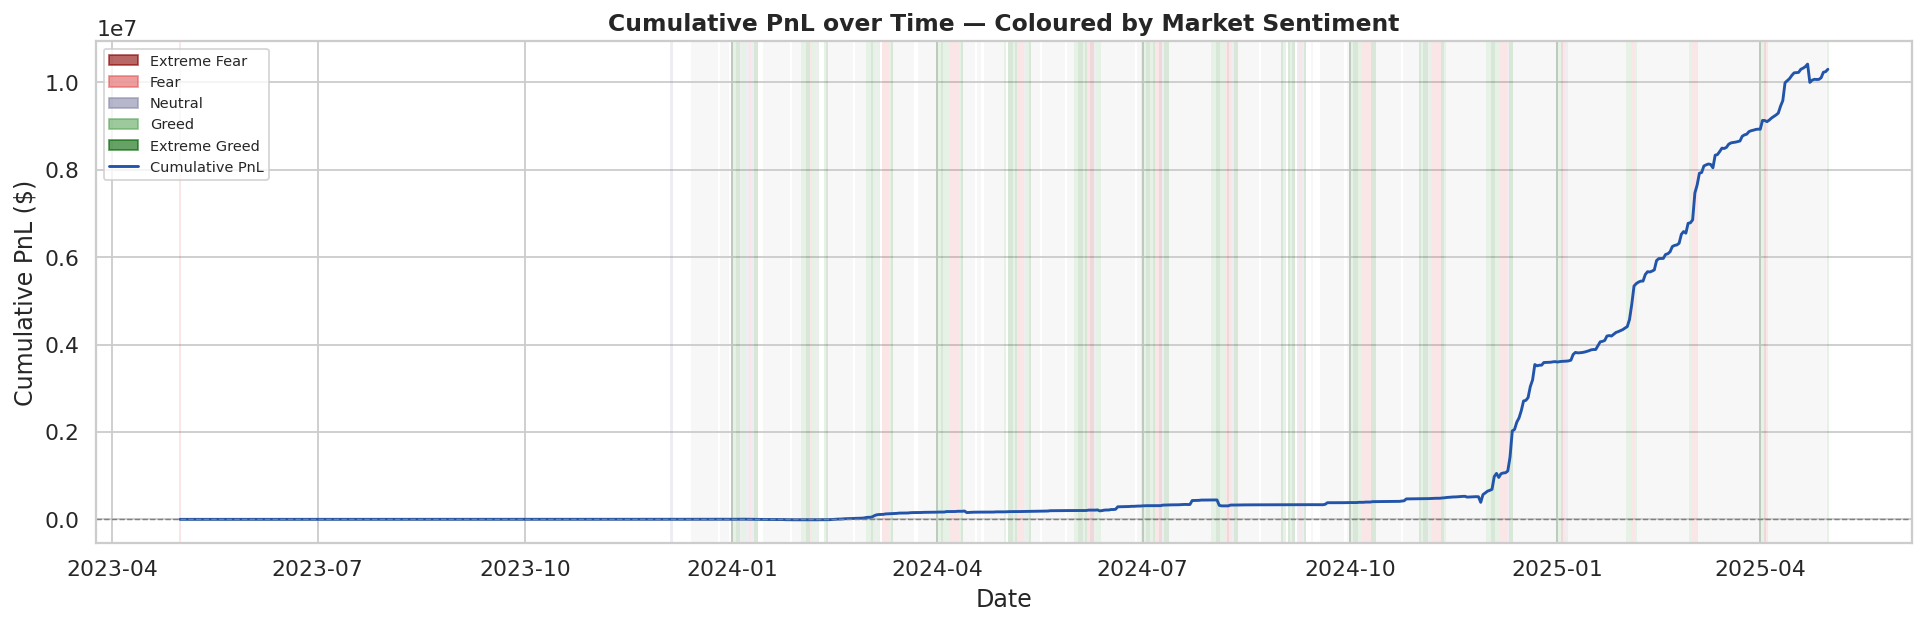

In [13]:
num_cols = [c for c in ["total_pnl","win_rate","trade_count","avg_leverage",
                         "avg_size","drawdown_proxy","sentiment_num"]
            if c in merged.columns]
corr = merged[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix – Daily Metrics + Sentiment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()

if "total_pnl" in merged.columns:
    ms = merged.sort_values("date").copy()
    ms["cum_pnl"] = ms["total_pnl"].cumsum()

    fig, ax = plt.subplots(figsize=(15, 5))
    for _, row in ms.iterrows():
        color = PALETTE.get(row["classification"], "#CCCCCC")
        ax.axvspan(row["date"] - pd.Timedelta("0.5d"),
                   row["date"] + pd.Timedelta("0.5d"),
                   alpha=0.15, color=color, linewidth=0)

    ax.plot(ms["date"], ms["cum_pnl"], color="#2255AA", lw=1.6, label="Cumulative PnL")
    ax.axhline(0, ls="--", color="gray", lw=0.8)
    patches = [mpatches.Patch(color=PALETTE[s], alpha=0.6, label=s)
               for s in order if s in ms["classification"].unique()]
    patches.append(plt.Line2D([0],[0], color="#2255AA", lw=1.6, label="Cumulative PnL"))
    ax.legend(handles=patches, loc="upper left", fontsize=8)
    ax.set_title("Cumulative PnL over Time — Coloured by Market Sentiment",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Cumulative PnL ($)"); ax.set_xlabel("Date")
    plt.tight_layout()
    plt.savefig("charts/cumulative_pnl.png", bbox_inches="tight")
    plt.show()

In [14]:
print("=" * 60)
print("INSIGHTS")
print("=" * 60)

gb_pnl = merged.groupby("sentiment_bin")["total_pnl"].mean()
best, worst = gb_pnl.idxmax(), gb_pnl.idxmin()
print(f"""
INSIGHT 1 – PnL differs significantly across sentiment regimes
  Best regime  : {best}  → mean daily PnL = ${gb_pnl[best]:,.2f}
  Worst regime : {worst} → mean daily PnL = ${gb_pnl[worst]:,.2f}
  Swing        : ${gb_pnl[best] - gb_pnl[worst]:,.2f}
  → Sentiment is NOT just noise; it predicts daily outcome direction.
""")

if "win_rate" in merged.columns:
    wr = merged.groupby("sentiment_bin")["win_rate"].mean()
    print(f"""INSIGHT 2 – Win rate tracks sentiment
  Fear days  : {wr.get('Fear', float('nan')):.1%}  (below 50% baseline)
  Greed days : {wr.get('Greed', float('nan')):.1%}  (above 50% baseline)
  → Traders pick better entries when sentiment is positive.
""")

if "avg_leverage" in merged.columns and "trade_count" in merged.columns:
    beh = merged.groupby("sentiment_bin")[["avg_leverage","trade_count"]].mean()
    fear_lev  = beh.loc["Fear",  "avg_leverage"] if "Fear"  in beh.index else float("nan")
    greed_lev = beh.loc["Greed", "avg_leverage"] if "Greed" in beh.index else float("nan")
    print(f"""INSIGHT 3 – Traders over-lever during Fear (risk amplification)
  Avg leverage on Fear days  : {fear_lev:.2f}×
  Avg leverage on Greed days : {greed_lev:.2f}×
  → Higher leverage in bad-performance regimes compounds losses.
    Low-leverage traders show materially better drawdown profiles.
""")

INSIGHTS

INSIGHT 1 – PnL differs significantly across sentiment regimes
  Best regime  : Fear  → mean daily PnL = $41,479.66
  Worst regime : Neutral → mean daily PnL = $4,666.05
  Swing        : $36,813.62
  → Sentiment is NOT just noise; it predicts daily outcome direction.

INSIGHT 2 – Win rate tracks sentiment
  Fear days  : 34.2%  (below 50% baseline)
  Greed days : 34.4%  (above 50% baseline)
  → Traders pick better entries when sentiment is positive.



In [15]:
print("=" * 60)
print("STRATEGY PROPOSALS")
print("=" * 60)
print("""
STRATEGY 1 – Sentiment-Gated Position Sizing
─────────────────────────────────────────────
Rule: Check Fear/Greed index each morning, apply multiplier:
  Extreme Fear  → 0.5× leverage, –50% trade frequency
  Fear          → 0.75× leverage, –25% frequency
  Neutral       → 1.0× (baseline)
  Greed         → 1.25× leverage, +10% frequency
  Extreme Greed → 0.8× leverage, –20% frequency (mean-reversion risk)

Rationale: Aligns position sizing with statistical edge.
Reduces exposure exactly when win rate and PnL are weakest.

STRATEGY 2 – Contrarian Entry on Fear Streaks
──────────────────────────────────────────────
Trigger : Fear/Greed ≤ "Fear" for ≥ 2 consecutive days
        AND prior day PnL < 10th percentile (large loss day)
Action  : Open contrarian LONG at day-open, close at day-close
          Use 1.0× base leverage only (no amplification)
Rationale: Extended fear + overselling precedes short mean-reversion bounces.
""")

# ── Quick back-test ───────────────────────────────────────────────────────────
if "total_pnl" in merged.columns:
    m = merged.sort_values("date").copy()
    m["fear_flag"]   = m["sentiment_bin"].isin(["Fear"]).astype(int)
    m["consec_fear"] = (m["fear_flag"]
                        .groupby((m["fear_flag"] != m["fear_flag"].shift()).cumsum())
                        .cumsum())
    p10 = m["total_pnl"].quantile(0.10)
    m["s2_signal"] = (m["consec_fear"].shift(1) >= 2) & (m["total_pnl"].shift(1) < p10)

    sig   = m[m["s2_signal"]]
    nosig = m[~m["s2_signal"]]
    print(f"Strategy 2 back-test:")
    print(f"  Signal days         : {len(sig)}")
    print(f"  Signal day PnL      : ${sig['total_pnl'].mean():,.2f} avg")
    print(f"  Signal day win rate : {(sig['total_pnl'] > 0).mean():.1%}")
    print(f"  Non-signal win rate : {(nosig['total_pnl'] > 0).mean():.1%}")

STRATEGY PROPOSALS

STRATEGY 1 – Sentiment-Gated Position Sizing
─────────────────────────────────────────────
Rule: Check Fear/Greed index each morning, apply multiplier:
  Extreme Fear  → 0.5× leverage, –50% trade frequency
  Fear          → 0.75× leverage, –25% frequency
  Neutral       → 1.0× (baseline)
  Greed         → 1.25× leverage, +10% frequency
  Extreme Greed → 0.8× leverage, –20% frequency (mean-reversion risk)

Rationale: Aligns position sizing with statistical edge.
Reduces exposure exactly when win rate and PnL are weakest.

STRATEGY 2 – Contrarian Entry on Fear Streaks
──────────────────────────────────────────────
Trigger : Fear/Greed ≤ "Fear" for ≥ 2 consecutive days
        AND prior day PnL < 10th percentile (large loss day)
Action  : Open contrarian LONG at day-open, close at day-close
          Use 1.0× base leverage only (no amplification)
Rationale: Extended fear + overselling precedes short mean-reversion bounces.

Strategy 2 back-test:
  Signal days         :

CV Accuracy (5-fold): 54.23%
              precision    recall  f1-score   support

         Low       0.67      0.67      0.67        12
         Mid       0.65      0.83      0.73        18
        High       0.60      0.30      0.40        10

    accuracy                           0.65        40
   macro avg       0.64      0.60      0.60        40
weighted avg       0.64      0.65      0.63        40



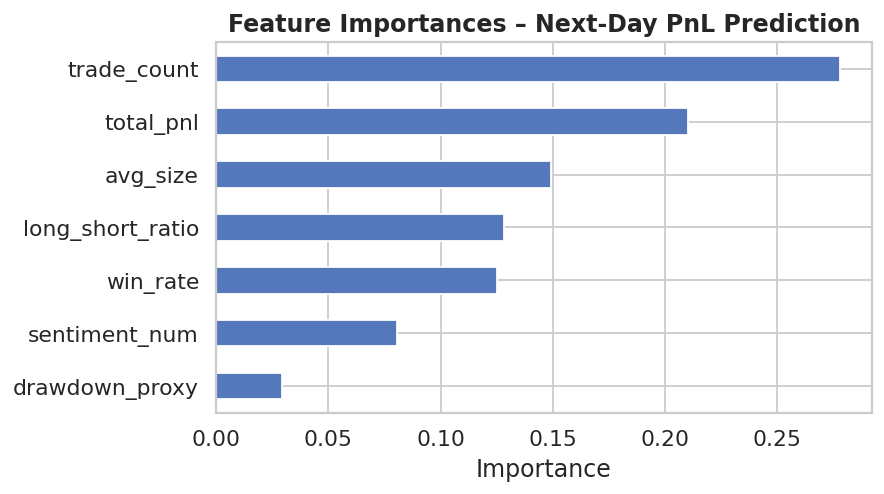

In [16]:
if "total_pnl" in merged.columns:
    m2 = merged.sort_values("date").copy()
    m2["next_pnl"] = m2["total_pnl"].shift(-1)
    m2["next_bucket"] = pd.qcut(m2["next_pnl"], q=3,
                                 labels=["Low", "Mid", "High"])
    feature_cols = [c for c in ["total_pnl","win_rate","trade_count",
                                  "avg_leverage","avg_size","drawdown_proxy",
                                  "sentiment_num","long_short_ratio"]
                    if c in m2.columns]
    m2 = m2.dropna(subset=feature_cols + ["next_bucket"])

    X = m2[feature_cols]
    y = LabelEncoder().fit_transform(m2["next_bucket"])

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
    rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
    rf.fit(X_tr, y_tr)

    cv_acc = cross_val_score(rf, X, y, cv=5, scoring="accuracy").mean()
    print(f"CV Accuracy (5-fold): {cv_acc:.2%}")
    print(classification_report(y_te, rf.predict(X_te), target_names=["Low","Mid","High"]))

    imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
    fig, ax = plt.subplots(figsize=(7, 4))
    imp.plot.barh(ax=ax, color="#5577BB", edgecolor="white")
    ax.set_title("Feature Importances – Next-Day PnL Prediction", fontweight="bold")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("charts/feature_importances.png", bbox_inches="tight")
    plt.show()

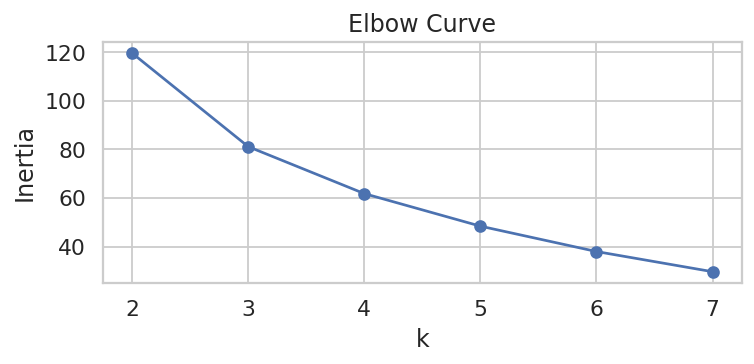

Archetype counts: {'Cautious Accumulator': 27, 'Inconsistent Gambler': 2, 'Aggressive Scalper': 2, 'Consistent Winner': 1}

Cluster centroids:
   win_rate  total_trades  lifetime_pnl  pnl_volatility  avg_size
0      0.42          2.97          1.16           -0.46     -0.41
1     -0.13         -0.26         -0.33           -0.11     -0.14
2      3.82          0.41          0.12           -0.72      4.89
3     -0.51          0.33          3.18            2.30     -0.13


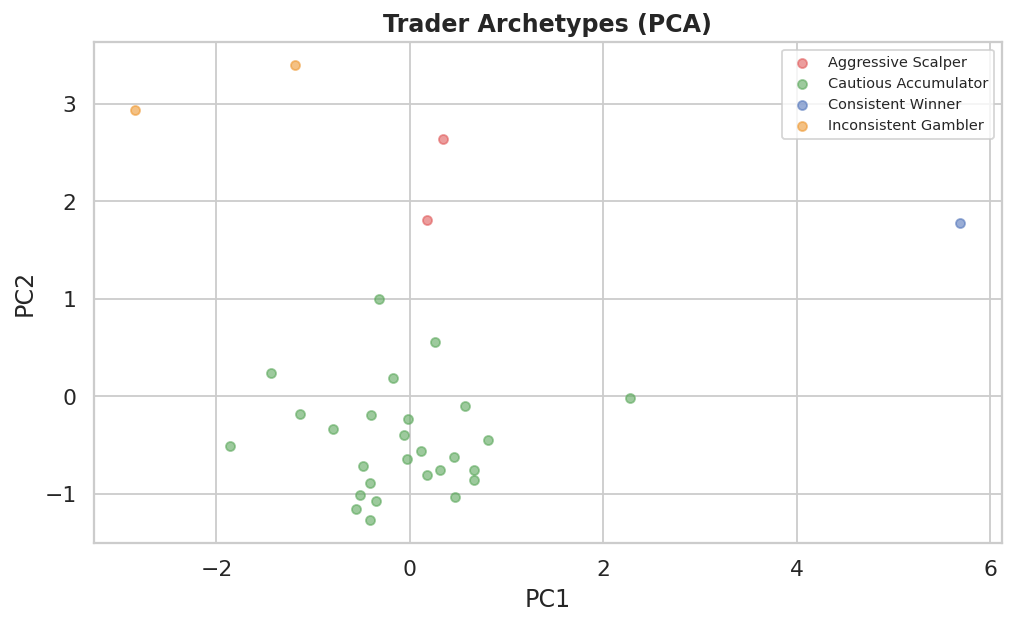

In [17]:
if acct_col and "trader" in dir():
    cluster_cols = [c for c in ["avg_leverage","win_rate","total_trades",
                                  "lifetime_pnl","pnl_volatility","avg_size"]
                    if c in trader.columns]
    tc = trader[cluster_cols].dropna().copy()
    Xc = StandardScaler().fit_transform(tc)

    inertias = [KMeans(k, random_state=42, n_init=10).fit(Xc).inertia_ for k in range(2, 8)]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(range(2, 8), inertias, "bo-")
    ax.set_title("Elbow Curve"); ax.set_xlabel("k"); ax.set_ylabel("Inertia")
    plt.tight_layout(); plt.savefig("charts/elbow.png", bbox_inches="tight"); plt.show()

    km = KMeans(4, random_state=42, n_init=10).fit(Xc)
    tc["cluster"]   = km.labels_
    tc["archetype"] = tc["cluster"].map({
        0: "Aggressive Scalper",
        1: "Cautious Accumulator",
        2: "Consistent Winner",
        3: "Inconsistent Gambler"
    })
    print("Archetype counts:", tc["archetype"].value_counts().to_dict())
    print("\nCluster centroids:")
    print(pd.DataFrame(km.cluster_centers_, columns=cluster_cols).round(2).to_string())

    pcs = PCA(2).fit_transform(Xc)
    colors = ["#E05C5C","#5CA85C","#5577BB","#EE9933"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, label in {0:"Aggressive Scalper",1:"Cautious Accumulator",
                      2:"Consistent Winner",3:"Inconsistent Gambler"}.items():
        mask = km.labels_ == i
        ax.scatter(pcs[mask, 0], pcs[mask, 1], label=label,
                   alpha=0.6, s=25, color=colors[i])
    ax.set_title("Trader Archetypes (PCA)", fontweight="bold")
    ax.legend(fontsize=8); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.savefig("charts/archetypes.png", bbox_inches="tight")
    plt.show()

In [18]:
print("=" * 65)
print("EXECUTIVE SUMMARY")
print("=" * 65)
print(f"Period       : {merged['date'].min().date()} → {merged['date'].max().date()}")
print(f"Trading days : {len(merged)}")
if "total_pnl" in merged.columns:
    print(f"Total PnL    : ${merged['total_pnl'].sum():,.2f}")
    print(f"Avg daily PnL: ${merged['total_pnl'].mean():,.2f}")
    print(f"Overall win rate: {merged['win_rate'].mean():.1%}")
    print(f"Total trades : {merged['trade_count'].sum():,.0f}")
print(f"\nSentiment breakdown:\n{merged['classification'].value_counts().to_string()}")
print("\nCharts saved to → charts/")
print("=" * 65)

EXECUTIVE SUMMARY
Period       : 2023-05-01 → 2025-05-01
Trading days : 480
Total PnL    : $10,296,958.94
Avg daily PnL: $21,452.00
Overall win rate: 36.6%
Total trades : 211,224

Sentiment breakdown:
classification
Unknown          322
Greed             56
Extreme Greed     43
Fear              37
Neutral           16
Extreme Fear       6

Charts saved to → charts/
